In [26]:
# %% [markdown]
# ## 🚀 Connexion à la base SQLite + chargement Excel

# %%
import pandas as pd
import sqlite3
from datetime import datetime, timedelta
from pathlib import Path
import re
from IPython.display import display

# Chemins
DB_PATH = Path("SuperMarket1.db")
XLSX_PATH = Path("PourInsertionBD.xlsx")

# Connexion à la base
conn = sqlite3.connect(DB_PATH)
conn.execute("PRAGMA foreign_keys = ON;")
print("✅ Connexion SQLite OK")


✅ Connexion SQLite OK


In [27]:
# %% [markdown]
# ## 🔧 Fonctions utilitaires (dates, texte, validation)

# %%
EXCEL_BASE = datetime(1899, 12, 30)

def excel_to_iso(val):
    if pd.isna(val):
        return None
    if isinstance(val, (datetime, pd.Timestamp)):
        return val.strftime("%Y-%m-%d")
    try:
        return (EXCEL_BASE + timedelta(days=int(float(val)))).strftime("%Y-%m-%d")
    except:
        for fmt in ("%Y-%m-%d", "%d/%m/%Y", "%d/%m/%y"):
            try:
                return datetime.strptime(str(val).strip(), fmt).strftime("%Y-%m-%d")
            except:
                continue
        return None

def is_valid_iso_date(val):
    return bool(re.fullmatch(r"\d{4}-\d{2}-\d{2}", str(val)))

def clean_text(val):
    return str(val).strip() if not pd.isna(val) else None

def insert_valid_rows(df, table_name, conn):
    try:
        rows = df.to_sql(table_name, conn, if_exists="append", index=False)
        print(f"✅ {table_name} : {rows} lignes insérées")
    except Exception as e:
        print(f"❌ Insertion échouée dans {table_name} : {e}")


In [28]:
# %% [markdown]
# ## 📥 Chargement du fichier Excel

# %%
xls = pd.ExcelFile(XLSX_PATH)
print("📊 Feuilles détectées :", xls.sheet_names)


📊 Feuilles détectées : ['Vente Détail', 'Produits', 'Clients', 'Calendrier', 'Employé']


In [21]:
# %% [markdown]
# ## ✅ Bloc 4 : Insertion `Clients` avec commit + filtrage strict

# %%
# Lecture
df_cli = pd.read_excel(xls, "Clients")

# Corrige si mauvaise orthographe de la colonne ID
col_id = "CUSTOMER_ID" if "CUSTOMER_ID" in df_cli.columns else "CUSTUMER_ID"

# Nettoyage
df_cli["CUSTOMER_ID"] = df_cli[col_id].apply(clean_text)
df_cli["date_inscription"] = df_cli["date_inscription"].apply(excel_to_iso)

# Validation stricte
def is_valid_sqlite_date(s):
    return isinstance(s, str) and bool(re.fullmatch(r"\d{4}-\d{2}-\d{2}", s))

df_cli["__valid_date__"] = df_cli["date_inscription"].apply(is_valid_sqlite_date)

# Filtrage des lignes valides
df_valid = df_cli[
    df_cli["CUSTOMER_ID"].notna() &
    df_cli["__valid_date__"]
][["CUSTOMER_ID", "date_inscription"]].copy()

# Lignes rejetées
rejected = df_cli[~df_cli.index.isin(df_valid.index)]
if not rejected.empty:
    print("⚠️ Lignes rejetées (Clients — dates invalides) :")
    display(rejected[["CUSTOMER_ID", "date_inscription"]])

# Insertion avec commit
try:
    rows = df_valid.to_sql("Clients", conn, if_exists="append", index=False)
    conn.commit()  # 🔥 Commit ici
    print(f"✅ Clients : {rows} lignes insérées avec succès.")
except Exception as e:
    print("❌ Insertion échouée dans Clients :", e)


✅ Clients : 2297 lignes insérées avec succès.


In [22]:
# %% [markdown]
# ## 🔍 Vérification : données insérées dans `Clients`

# %%
df_check = pd.read_sql_query("SELECT * FROM Clients LIMIT 5;", conn)
display(df_check)


,CUSTOMER_ID,date_inscription
0,CUST-2KYXXXW1NK7I,2023-07-17
1,CUST-NR43XRT2PXYG,2023-09-07
2,CUST-CH58P8PSVIYU,2021-08-24
3,CUST-CI7JQHW4TIYT,2021-12-22
4,CUST-3QHP3KL4NPP2,2020-12-20


In [25]:
# %% [markdown]
# ## 🧑‍💼 Bloc 5 : Insertion table `Employé` (CHECK simplifié sur date_debut)

# %%
df_emp = pd.read_excel(xls, "Employé")

# Nettoyage des colonnes
df_emp_clean = df_emp.assign(
    id_employe=df_emp["id_employe"].astype(str).str.strip().str.lower(),
    employe=df_emp["employe"].astype(str).str.strip(),
    prenom=df_emp["prenom"].astype(str).str.strip(),
    nom=df_emp["nom"].astype(str).str.strip(),
    date_debut=df_emp["date_debut"].apply(excel_to_iso),  # conversion si possible
    hash_mdp=df_emp["hash_mdp"].astype(str).str.strip(),
    mail=df_emp["mail"].astype(str).str.strip()
)

# ✅ Nouveau filtre : date_debut non nulle et longueur >= 8
df_emp_clean["__valid_date__"] = df_emp_clean["date_debut"].apply(
    lambda x: isinstance(x, str) and len(x) >= 8
)

df_emp_valid = df_emp_clean[
    df_emp_clean["id_employe"].notna() &
    df_emp_clean["__valid_date__"]
].copy()

# Colonnes finales
df_emp_valid = df_emp_valid[[
    "id_employe", "employe", "prenom", "nom", "date_debut", "hash_mdp", "mail"
]]

# Lignes rejetées
rejected_emp = df_emp_clean[~df_emp_clean.index.isin(df_emp_valid.index)]
if not rejected_emp.empty:
    print("⚠️ Lignes rejetées (Employé — date_debut trop courte ou vide) :")
    display(rejected_emp[["id_employe", "date_debut"]])

# Insertion avec commit
try:
    rows = df_emp_valid.to_sql("Employé", conn, if_exists="append", index=False)
    conn.commit()  # 🔥 indispensable
    print(f"✅ Employé : {rows} lignes insérées avec succès.")
except Exception as e:
    print("❌ Insertion échouée dans Employé :", e)


✅ Employé : 56 lignes insérées avec succès.


In [29]:
# %% [markdown]
# ## 🧾 Bloc 6 : Insertion table `Vente Détail` (CHECK simplifié sur Date_achat)

# %%
df_vd = pd.read_excel(xls, "Vente Détail")

# Nettoyage des colonnes
df_vd_clean = df_vd.assign(
    ID_BDD=df_vd["ID_BDD"].apply(clean_text),
    CUSTOMER_ID=df_vd["CUSTOMER_ID"].apply(clean_text),
    id_employe=df_vd["id_employe"].astype(str).str.strip().str.lower(),
    EAN=df_vd["EAN"].apply(clean_text),
    Date_achat=df_vd["Date achat"].apply(excel_to_iso),  # conversion si possible
    ID_ticket=df_vd["ID ticket"].apply(clean_text)
)

# ✅ Nouveau filtre : Date_achat non nulle et longueur >= 8
df_vd_clean["__valid_date__"] = df_vd_clean["Date_achat"].apply(
    lambda x: isinstance(x, str) and len(x) >= 8
)

df_vd_valid = df_vd_clean[
    df_vd_clean["ID_BDD"].notna() &
    df_vd_clean["CUSTOMER_ID"].notna() &
    df_vd_clean["id_employe"].notna() &
    df_vd_clean["EAN"].notna() &
    df_vd_clean["__valid_date__"]
].copy()

# Colonnes finales
df_vd_valid = df_vd_valid[[
    "ID_BDD", "CUSTOMER_ID", "id_employe", "EAN", "Date_achat", "ID_ticket"
]]

# Lignes rejetées
rejected_vd = df_vd_clean[~df_vd_clean.index.isin(df_vd_valid.index)]
if not rejected_vd.empty:
    print("⚠️ Lignes rejetées (Vente Détail — Date_achat trop courte ou vide) :")
    display(rejected_vd[["ID_BDD", "CUSTOMER_ID", "Date_achat"]])

# Insertion avec commit
try:
    rows = df_vd_valid.to_sql("Vente Détail", conn, if_exists="append", index=False)
    conn.commit()  # 🔥 indispensable
    print(f"✅ Vente Détail : {rows} lignes insérées avec succès.")
except Exception as e:
    print("❌ Insertion échouée dans Vente Détail :", e)


✅ Vente Détail : 41377 lignes insérées avec succès.


In [31]:
# %% [markdown]
# ## 💶 Chiffre d'affaires du 14 août 2024

# %%
sql_ca = """
SELECT v."Date_achat" AS date_achat,
       ROUND(SUM(p.prix), 2) AS chiffre_affaires
FROM "Vente Détail" v
JOIN Produits p ON v.EAN = p.EAN
WHERE v."Date_achat" = '2024-08-14'
GROUP BY v."Date_achat";
"""

df_ca = pd.read_sql_query(sql_ca, conn)
display(df_ca)


,date_achat,chiffre_affaires
0,2024-08-14,284243.88


In [32]:
# %% [markdown]
# ## 💶 Chiffre d'affaires par client (Top 10)

# %%
sql_top_clients = """
SELECT v.CUSTOMER_ID,
       ROUND(SUM(p.prix), 2) AS chiffre_affaires
FROM "Vente Détail" v
JOIN Produits p ON v.EAN = p.EAN
GROUP BY v.CUSTOMER_ID
ORDER BY chiffre_affaires DESC
LIMIT 10;
"""

df_top_clients = pd.read_sql_query(sql_top_clients, conn)
display(df_top_clients)


,CUSTOMER_ID,chiffre_affaires
0,CUST-JNSOZSFORR88,846.86
1,CUST-GM6VBAYAB8SF,666.86
2,CUST-L2ST2JHI7K9O,644.18
3,CUST-WU7ZKQJE4L17,608.93
4,CUST-9WM83101QDTI,582.03
5,CUST-ZMAOVX8XYGJY,576.39
6,CUST-3K66CV0OHH7Q,571.44
7,CUST-CG23SXJDRNYR,531.09
8,CUST-D8IOFHVUFX3Y,477.35
9,CUST-IHN1HQRI7PYJ,463.73


In [33]:
# %% [markdown]
# ## 💶 Part du chiffre d'affaires par employé

# %%
sql_ca_employe = """
WITH ca_par_employe AS (
    SELECT v.id_employe,
           ROUND(SUM(p.prix), 2) AS ca_employe
    FROM "Vente Détail" v
    JOIN Produits p ON v.EAN = p.EAN
    GROUP BY v.id_employe
),
ca_total AS (
    SELECT SUM(ca_employe) AS ca_global FROM ca_par_employe
)
SELECT e.id_employe,
       e.prenom || ' ' || e.nom AS employe,
       c.ca_employe,
       ROUND(c.ca_employe * 100.0 / t.ca_global, 2) AS part_pourcent
FROM ca_par_employe c
JOIN ca_total t ON 1=1
JOIN Employé e ON e.id_employe = c.id_employe
ORDER BY part_pourcent DESC;
"""

df_ca_employe = pd.read_sql_query(sql_ca_employe, conn)
display(df_ca_employe)


,id_employe,employe,ca_employe,part_pourcent
0,f491076a1ff2d873ebea809c11144542,Adélie Boulet,7818.82,2.75
1,e01e752175e05f00c8314ccb8da4c418,Eugène Jacquier,7736.16,2.72
2,8d1001fbad3d2a60ff7530600ed5d55e,Charlène Delisle,6995.14,2.46
3,6c1c3292c852c6c593b95cc146b00c0e,Pierre Manoury,6616.46,2.33
4,a7ada0770091e838e3dcd45265282820,Tristan Arsenault,6483.84,2.28
5,2477db17c02f512ebc4b20f01a7edb55,Auriane Dufresne,6361.22,2.24
6,528c733809cb51a3634befb260b5d243,Abelin Dutertre,6133.34,2.16
7,1c1d83678cc463b52366dae07cd14c8a,Pierre Ange,6112.37,2.15
8,dd595f0f0b3400df2908f0be7723dad4,Arnaud Lièvremont,6111.18,2.15
9,c4f0909120cfde7086a3c1a56e96a015,Patricia Rodier,6094.62,2.14


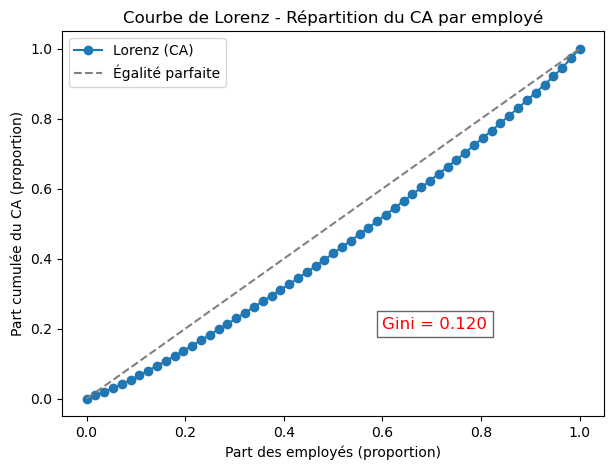

,id_employe,employe,ca_employe
0,f491076a1ff2d873ebea809c11144542,Adélie Boulet,7818.82
1,e01e752175e05f00c8314ccb8da4c418,Eugène Jacquier,7736.16
2,8d1001fbad3d2a60ff7530600ed5d55e,Charlène Delisle,6995.14
3,6c1c3292c852c6c593b95cc146b00c0e,Pierre Manoury,6616.46
4,a7ada0770091e838e3dcd45265282820,Tristan Arsenault,6483.84
5,2477db17c02f512ebc4b20f01a7edb55,Auriane Dufresne,6361.22
6,528c733809cb51a3634befb260b5d243,Abelin Dutertre,6133.34
7,1c1d83678cc463b52366dae07cd14c8a,Pierre Ange,6112.37
8,dd595f0f0b3400df2908f0be7723dad4,Arnaud Lièvremont,6111.18
9,c4f0909120cfde7086a3c1a56e96a015,Patricia Rodier,6094.62


In [39]:
# %% [markdown]
# ## 📊 Courbe de Lorenz + Indice de Gini pour le CA par employé

# %%
# Requête SQL pour obtenir le CA par employé
sql_ca_employe = """
SELECT v.id_employe,
       e.prenom || ' ' || e.nom AS employe,
       ROUND(SUM(p.prix), 2) AS ca_employe
FROM "Vente Détail" v
JOIN Produits p ON v.EAN = p.EAN
JOIN Employé e ON e.id_employe = v.id_employe
GROUP BY v.id_employe, employe
ORDER BY ca_employe DESC;
"""
df_ca_employe = pd.read_sql_query(sql_ca_employe, conn)

# --- Calcul Gini ---
values = df_ca_employe["ca_employe"].values
values_sorted = np.sort(values)  # tri croissant
n = len(values_sorted)

# Part cumulée du CA
cum_values = np.cumsum(values_sorted) / values_sorted.sum()
lorenz_curve = np.insert(cum_values, 0, 0)  # ajoute 0 au début
x = np.linspace(0, 1, len(lorenz_curve))

# Aire sous Lorenz
lorenz_area = np.trapz(lorenz_curve, x)
gini = 1 - 2 * lorenz_area

# --- Graphe ---
plt.figure(figsize=(7,5))
plt.plot(x, lorenz_curve, marker="o", label="Lorenz (CA)")
plt.plot([0,1], [0,1], linestyle="--", color="grey", label="Égalité parfaite")
plt.title("Courbe de Lorenz - Répartition du CA par employé")
plt.xlabel("Part des employés (proportion)")
plt.ylabel("Part cumulée du CA (proportion)")

# Ajouter valeur Gini sur le graphe
plt.text(0.6, 0.2, f"Gini = {gini:.3f}", fontsize=12, color="red", bbox=dict(facecolor="white", alpha=0.6))

plt.legend()
plt.show()

df_ca_employe.head(10)


,Rayon,ca_rayon,part_pct
0,Divers,136821.96,48.135411
1,l'oreal,20715.47,7.287921
2,gemey,16061.38,5.650563
3,champagnes,16030.03,5.639534
4,patisseries,11757.17,4.136297
5,coloration,8549.36,3.007755
6,rimmel,8396.30,2.953907
7,shampooings,8015.67,2.819997
8,plats cuisines,7345.44,2.584203
9,bebe,7185.30,2.527864


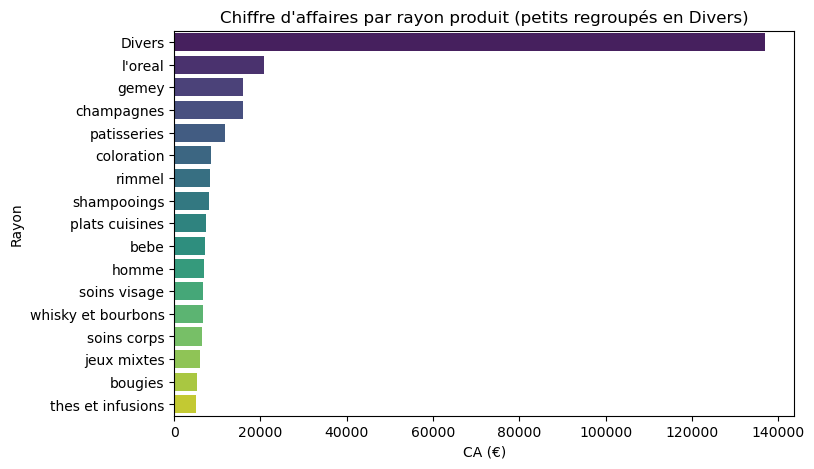

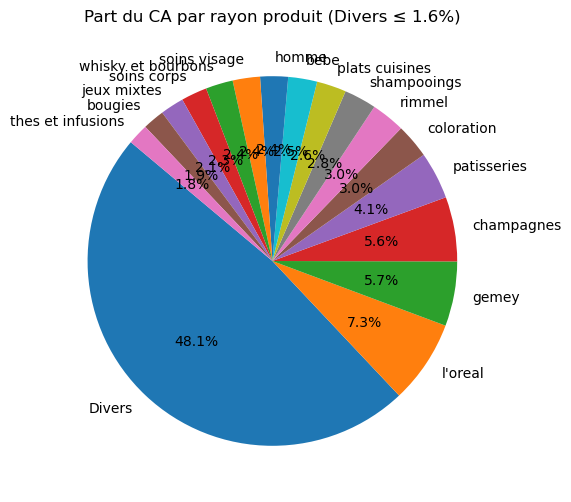

In [44]:
# %% [markdown]
# ## 🏬 Répartition du CA par rayon (regroupement des petits en Divers)

# %%
sql_ca_rayon = """
SELECT p.Rayon,
       SUM(p.prix) AS ca_rayon
FROM "Vente Détail" v
JOIN Produits p ON v.EAN = p.EAN
GROUP BY p.Rayon
ORDER BY ca_rayon DESC;
"""

df_ca_rayon = pd.read_sql_query(sql_ca_rayon, conn)

# Part du CA total
total_ca = df_ca_rayon["ca_rayon"].sum()
df_ca_rayon["part_pct"] = 100 * df_ca_rayon["ca_rayon"] / total_ca

# Regrouper les rayons ≤ 1% en "Divers"
df_main = df_ca_rayon[df_ca_rayon["part_pct"] > 1.6].copy()
df_divers = df_ca_rayon[df_ca_rayon["part_pct"] <= 1.6]

if not df_divers.empty:
    divers_sum = df_divers["ca_rayon"].sum()
    divers_pct = df_divers["part_pct"].sum()
    df_main = pd.concat([
        df_main,
        pd.DataFrame({"Rayon": ["Divers"], "ca_rayon": [divers_sum], "part_pct": [divers_pct]})
    ])

# Réordonner par CA décroissant
df_main = df_main.sort_values("ca_rayon", ascending=False).reset_index(drop=True)

# --- Affichage tableau ---
display(df_main)

# --- Graphique en barres ---
plt.figure(figsize=(8,5))
sns.barplot(data=df_main, x="ca_rayon", y="Rayon", palette="viridis")
plt.title("Chiffre d'affaires par rayon produit (petits regroupés en Divers)")
plt.xlabel("CA (€)")
plt.ylabel("Rayon")
plt.show()

# --- Graphique en camembert ---
plt.figure(figsize=(6,6))
plt.pie(df_main["ca_rayon"], labels=df_main["Rayon"], autopct="%1.1f%%", startangle=140)
plt.title("Part du CA par rayon produit (Divers ≤ 1.6%)")
plt.show()


## Partie 2 - Audit technique (execution automatique)

Cette section applique les triggers de durcissement sur une copie de la base, puis exécute les contrôles clés:
- CA du 14/08/2024
- Ventes loguées le 15/08/2024
- Vérification blocage insertion rétroactive
- Vérification blocage suppression dimension référencée

In [ ]:
import sqlite3
import shutil
from pathlib import Path

root = Path.cwd()
source_db = root / "SuperMarketOlap.db"
work_db = root / "data" / "validation_notebook.db"
work_db.parent.mkdir(parents=True, exist_ok=True)
shutil.copyfile(source_db, work_db)

con = sqlite3.connect(work_db)
cur = con.cursor()

# Appliquer le hardening sur la copie
hardening_sql = (root / "docus" / "02_hardening_triggers.sql").read_text(encoding="utf-8")
cur.executescript(hardening_sql)
cur.execute("UPDATE Batch_Control SET closed_date_excell = '45518' WHERE id = 1")
con.commit()

# Controle 1: CA du 14/08/2024
ca_14 = cur.execute(
    """
    SELECT ROUND(SUM(p.prix), 2)
    FROM Faits_Ventes v
    JOIN Dim_Produits p ON p.EAN = v.EAN
    WHERE v.Date_Achat = '45518'
    """
).fetchone()[0]

# Controle 2: nombre de ventes loguees le 15/08/2024
nb_15 = cur.execute(
    """
    SELECT COUNT(DISTINCT id_ligne)
    FROM Logs
    WHERE table_insert = 'Ventes'
      AND operation = 'INSERT'
      AND date = 45519
    """
).fetchone()[0]

# Controle 3: valeur des ventes loguees le 15/08/2024
ca_15_logs = cur.execute(
    """
    SELECT ROUND(SUM(p.prix), 2)
    FROM Faits_Ventes v
    JOIN Dim_Produits p ON p.EAN = v.EAN
    JOIN (
        SELECT DISTINCT id_ligne
        FROM Logs
        WHERE table_insert = 'Ventes'
          AND operation = 'INSERT'
          AND date = 45519
    ) l ON l.id_ligne = v.ID_BDD
    """
).fetchone()[0]

# Controle 4: blocage insertion retroactive
retro_blocked = False
try:
    cur.execute(
        """
        INSERT INTO Faits_Ventes
        (ID_BDD, CUSTOMER_ID, id_employe, EAN, Date_Achat, Id_Ticket)
        VALUES (?, ?, ?, ?, ?, ?)
        """,
        (
            "TEST_RETRO_NOTEBOOK",
            "CUST-2KYXXXW1NK7I",
            "b413ca065a762e8cf2e86cfea8b9c174",
            "1857802002765",
            "45517",
            "t_test"
        ),
    )
    con.commit()
except Exception:
    retro_blocked = True
    con.rollback()

# Controle 5: blocage suppression dimension referencee
delete_blocked = False
try:
    cur.execute("DELETE FROM Dim_Clients WHERE CUSTOMER_ID = 'CUST-2KYXXXW1NK7I'")
    con.commit()
except Exception:
    delete_blocked = True
    con.rollback()

print("=== Resultats Audit Partie 2 ===")
print(f"CA du 14/08/2024 (date_excell=45518): {ca_14}")
print(f"Nb ventes loguees le 15/08/2024 (date=45519): {nb_15}")
print(f"CA correspondant aux ventes loguees le 15/08/2024: {ca_15_logs}")
print(f"Blocage insertion retroactive: {'OK' if retro_blocked else 'KO'}")
print(f"Blocage suppression dimension referencee: {'OK' if delete_blocked else 'KO'}")

con.close()